In [1]:
import pandas as pd
import random
import numpy as np
from SingleRegionModel import SingleRegionModel
from pyomo.opt import SolverFactory
from pyomo.environ import *

In [2]:
wind = pd.read_csv('cleaned/wind.csv', index_col=0)
solar = pd.read_csv('cleaned/solar.csv', index_col=0)
demand = pd.read_csv('cleaned/demand.csv', index_col=0)

In [3]:
year_map = {
    2015:0,
    2016:1,
    2017:2,
    2018:3,
    2019:4
}

In [4]:
wind.index = pd.to_datetime(wind.index)
wind['year'] = wind.index.year.map(year_map)
wind.reset_index(inplace=True)
wind = wind.drop('index', axis = 1)

solar.index = pd.to_datetime(solar.index)
solar['year'] = solar.index.year.map(year_map)
solar.reset_index(inplace=True)
solar = solar.drop('index', axis = 1)

demand.index = pd.to_datetime(demand.index)
demand['year'] = demand.index.year.map(year_map)
demand.reset_index(inplace=True)
demand = demand.drop('index', axis = 1)

In [5]:
year_sample = demand[demand['year'] == 0]
season_index = len(year_sample) // 4

season1 = season_index
season2 = season_index * 2
season3 = season_index * 3

last = len(year_sample)

In [6]:
def scenario_random_sampling(n, l, peaks, peak_l):
    tot_seas = 4 + peaks
    total_season_length = (4 * l) + (peaks * peak_l)
    
    scenarios_info = {'num_seasons':tot_seas, 'regular_season':4, 'peak_season':peaks, 'regular_length':l, 
                      'peak_length':peak_l, 'scenario_length': total_season_length, 'num_scenario':n} 
    
    pd.DataFrame(scenarios_info, index=[0]).to_csv('scenarios/scenarios_info.csv')
    
    scenarios = []
    
    for i in range(n):
        
        random_year = random.randint(0, 4)
        
        wind_year = wind[wind['year'] == random_year]
        solar_year = solar[solar['year'] == random_year]
        demand_year = demand[demand['year'] == random_year]
        
        st_scenario = np.zeros(shape=(3,total_season_length))
        
        for s in range(1,5):
            if s == 1:
                h = random.randint(0, (season_index - l))
                st_scenario[0][:l] = wind_year.iloc[h: h+l]['capacity factor'] 
                st_scenario[1][:l] = solar_year.iloc[h: h+l]['capacity factor'] 
                st_scenario[2][:l] = demand_year.iloc[h: h+l]['demand'] 
            elif s == 2:
                h = random.randint(season_index, ((2*season_index) - l))
                st_scenario[0][l:l*2] = wind_year.iloc[h: h+l]['capacity factor']  
                st_scenario[1][l:l*2] = solar_year.iloc[h: h+l]['capacity factor']  
                st_scenario[2][l:l*2] = demand_year.iloc[h: h+l]['demand']  
            elif s == 3:
                h = random.randint((2*season_index), ((3*season_index) - l))
                st_scenario[0][l*2:l*3] = wind_year.iloc[h: h+l]['capacity factor']  
                st_scenario[1][l*2:l*3] = solar_year.iloc[h: h+l]['capacity factor']  
                st_scenario[2][l*2:l*3] = demand_year.iloc[h: h+l]['demand']  
            else:
                h = random.randint((3*season_index), (last - l ))
                st_scenario[0][l*3:l*4] = wind_year.iloc[h: h+l]['capacity factor']  
                st_scenario[1][l*3:l*4] = solar_year.iloc[h: h+l]['capacity factor']  
                st_scenario[2][l*3:l*4] = demand_year.iloc[h: h+l]['demand']  
        
        if peaks >= 1:
            
            demand_tmp = demand_year
            
            peak_start_idx = l*4 
            
            h = demand_tmp['demand'].idxmax()
            st_scenario[0][peak_start_idx:(peak_start_idx+peak_l)] = wind_year.loc[h-((peak_l//2)): h+(peak_l//2)]['capacity factor']  
            st_scenario[1][peak_start_idx:(peak_start_idx+peak_l)] = solar_year.loc[h-((peak_l//2)): h+(peak_l//2)]['capacity factor']  
            st_scenario[2][peak_start_idx:(peak_start_idx+peak_l)] = demand_year.loc[h-((peak_l//2)): h+(peak_l//2)]['demand']  
            
            demand_tmp = demand_tmp.drop(h)
            
            if peaks >= 2:
                s = 5
                j = 2
                while s < tot_seas:
                    s += 1
                    h = demand_tmp['demand'].idxmax()
                    st_scenario[0][(peak_start_idx+peak_l*(j-1)):(peak_start_idx+peak_l*j)] = wind_year.loc[h-((peak_l//2)): h+(peak_l//2)]['capacity factor']  
                    st_scenario[1][(peak_start_idx+peak_l*(j-1)):(peak_start_idx+peak_l*j)] = solar_year.loc[h-((peak_l//2)): h+(peak_l//2)]['capacity factor']  
                    st_scenario[2][(peak_start_idx+peak_l*(j-1)):(peak_start_idx+peak_l*j)] = demand_year.loc[h-((peak_l//2)): h+(peak_l//2)]['demand']  
                    
                    j += 1
                    
                    demand_tmp = demand_tmp.drop(h)
         
        scenarios.append(st_scenario)
    
    scenarios = np.array(scenarios)
                    
    return scenarios

# Generating and saving a scenario dataset

In [7]:
season_length = 96
num_peaks = 1
peak_length = 25
num_scenario = 250

In [ ]:
scenario_set = scenario_random_sampling(num_scenario, season_length, num_peaks, peak_length)
np.save('scenarios/scenarios.npy', scenario_set)

: 

In [9]:
season_length = 96
num_peaks = 1
peak_length = 25
num_scenario = 1000

In [ ]:
scenario_set = scenario_random_sampling(num_scenario, season_length, num_peaks, peak_length)
np.save('scenarios/test_scenarios.npy', scenario_set)

: 

# Analysis of the scenario data

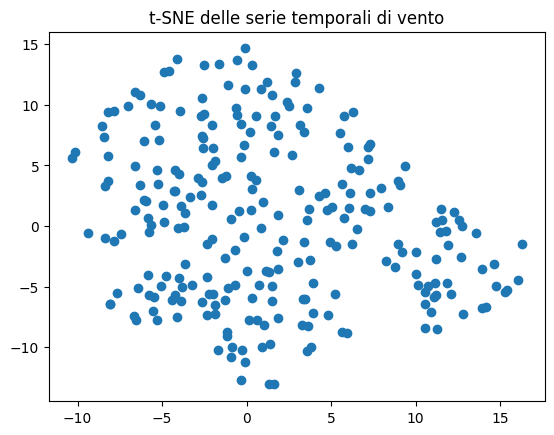

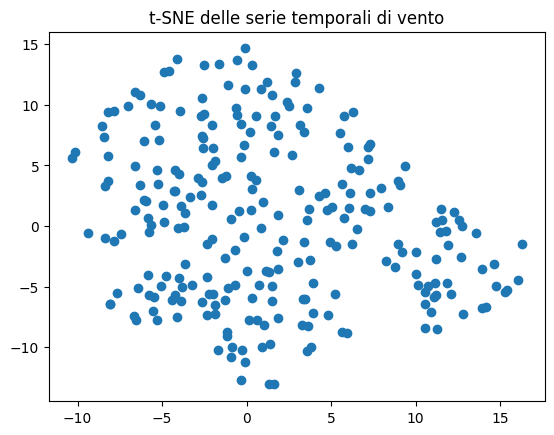

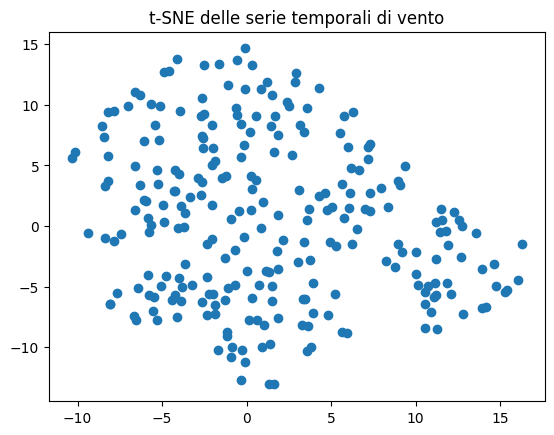

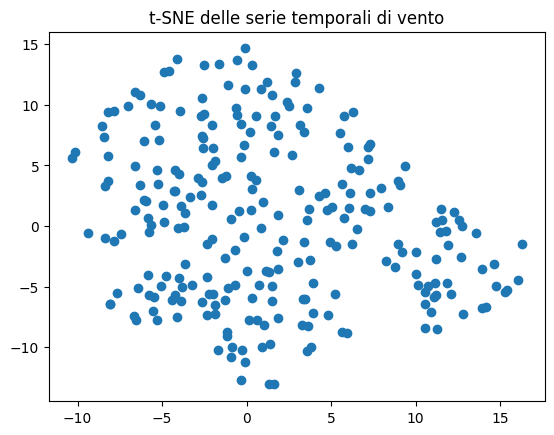

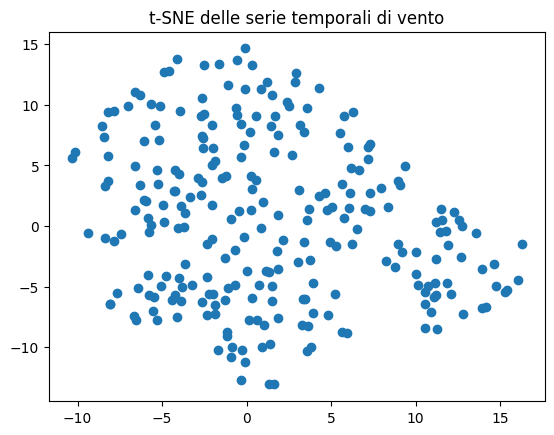

In [10]:
import ast
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

scenario_set = np.load('scenarios/scenarios.npy')
scenario_df = pd.read_csv('scenarios/scenario_dataset_cumulate.csv')

scenario_df = scenario_df[scenario_df['dataset_id'] == 0]

labels = {0: 'Wind', 1: 'Solar', 2: 'Demand'}

for idx, s in enumerate(scenario_df['indexes']):
    index_list = ast.literal_eval(s)
    scenarios = scenario_set[index_list]

    n_scenarios = len(index_list)  
    time_steps = scenarios.shape[-1]

    
    for i in range(3):
        X = scenario_set[:, i, :]   
        X_embedded = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X)

        if i == 0:
            plt.scatter(X_embedded[:,0], X_embedded[:,1])
            plt.title("t-SNE delle serie temporali di vento")
            plt.show() 

In [19]:
oos_sols = pd.read_csv('Results Independent Scenarios/Results 10 scenarios/oos_solutions_10.csv')

surrogate_cols = [col for col in oos_sols.columns if col.startswith("surrogate_")]

for col in surrogate_cols:
    diff_col = f"diff_{col}"          
    oos_sols[diff_col] = oos_sols[col] - oos_sols["deterministic"]
    
oos_sols[oos_sols['diff_surrogate_2'] < 0]

,Unnamed: 0,deterministic,surrogate_1,surrogate_2,surrogate_0,diff_surrogate_1,diff_surrogate_2,diff_surrogate_0
0,0,226072.093152,221718.620849,225720.180044,221605.173817,-4353.472303,-351.913108,-4466.919335
1,1,206693.237511,201180.170602,205026.427221,201538.654531,-5513.066909,-1666.810290,-5154.582980
2,2,276132.981733,289892.508640,274182.344694,288711.525203,13759.526907,-1950.637039,12578.543470
4,4,217129.090606,211829.861787,215693.233404,212098.745321,-5299.228819,-1435.857202,-5030.345285
8,8,221519.375223,216956.533950,220947.029755,216912.194522,-4562.841273,-572.345468,-4607.180701
...,...,...,...,...,...,...,...,...
177,177,207749.259895,200701.554574,204232.815432,201748.380551,-7047.705321,-3516.444463,-6000.879344
182,182,206931.302953,202591.765592,206706.738533,202386.576139,-4339.537362,-224.564420,-4544.726814
188,188,209392.241017,203534.487843,207328.664831,204005.105917,-5857.753173,-2063.576186,-5387.135099
192,192,208450.092810,202779.724142,206590.168387,203210.437181,-5670.368668,-1859.924423,-5239.655629


In [7]:
test_scen = np.load('scenarios/test_scenarios.npy')
suspected_scen = test_scen[[28,89,109,115]]

normal_mask = np.ones(len(test_scen), dtype=bool)
normal_mask[[28,89,109,115]] = False
normal_scen = test_scen[normal_mask]
normal_scen = normal_scen[:200]

normal_means_per_scenario = normal_scen.mean(axis=2)    
outlier_means_per_scenario = suspected_scen.mean(axis=2)

normal_global_mean = normal_means_per_scenario.mean(axis=0)  
outlier_global_mean = outlier_means_per_scenario.mean(axis=0)

print(normal_global_mean)
print(outlier_global_mean)

[ 0.28992119  0.10576733 36.55324633]
[ 0.17093894  0.10654401 40.08324358]


In [9]:
scen1 = test_scen[201]
means_1 = scen1.mean(axis=1) 
means_1

array([ 0.26921809,  0.1186577 , 35.12746557])

In [11]:
scen2 = test_scen[203]
means_2 = scen2.mean(axis=1) 
means_2

array([ 0.34628606,  0.1318313 , 35.90002608])

In [12]:
scen3 = test_scen[204]
means_3 = scen3.mean(axis=1) 
means_3

array([ 0.20946553,  0.11720905, 36.55266585])

In [15]:
scen4 = test_scen[208]
means_4 = scen4.mean(axis=1) 
means_4

array([ 0.35680599,  0.1297335 , 35.88145212])